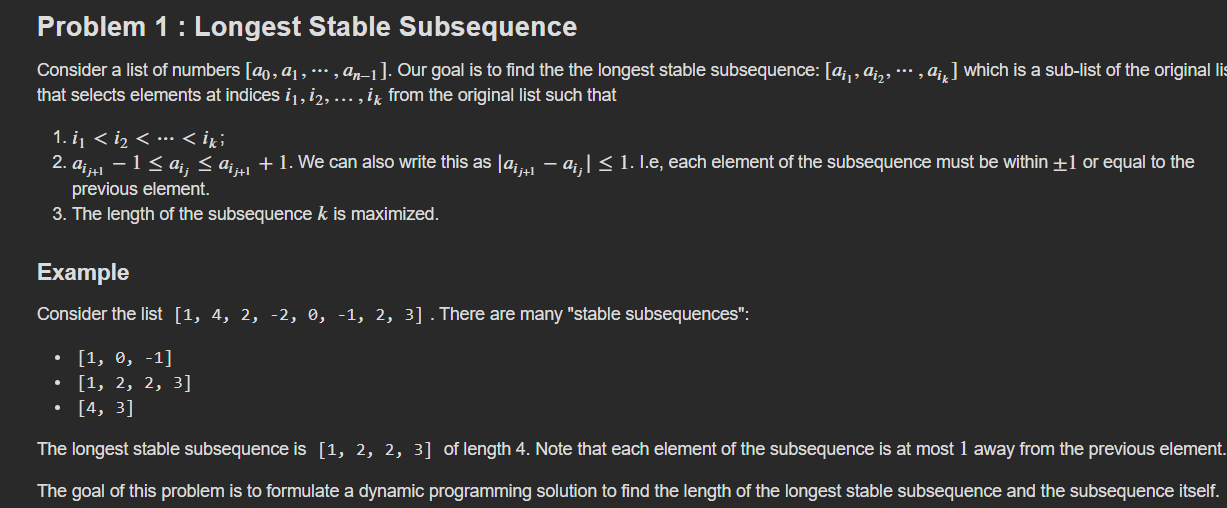

In [95]:
import numpy as np

def GetMatrixValue(matrix, i,j,n ):
    assert 0>= -1 and i < n
    assert 0>= -1 and j < n
    if(i<0 or j<0):
        return 0
    else:
        return matrix[i][j]
    
def output_matrix_lists(matrix):
    for row in matrix:
        print(f'{row}')

def output_matrix(matrix, x_dim, y_dim):
    for x in range(x_dim):
        print("")
        for y in range(y_dim):
            print(f'{matrix[x][y]}', end=",")


def lssLength_wrongchoiceforDP(array):
    n = len(array)
    j_value_used = []*n
    matrix = [[-1 if row>column else 0 for column in range(n)] for row in range(n)]
    
    # output_matrix_lists(matrix)
    # print(np.matrix(matrix))
    for col in range(1,n):
        for row in range(col):
            max_previous = 0 if 0==row else  max(all_row[row] for all_row in matrix)
            matrix[row][col] = max_previous+1 if abs(array[col]-array[row])<=1 else max_previous
            if 5==col and 2==row:
                print(f'{array[col]}, {array[row]},{max_previous},{matrix[row][col]}')
    
    print(np.matrix(matrix))

    for col in range(n-1,1,-1):
        current_max = max(all_row[col] for all_row in matrix)
        previous_max = max(all_row[col-1] for all_row in matrix)
        if current_max != previous_max:
            print(f'{array[col],array[col-1]}')

    return max(all_row[n-1] for all_row in matrix)+1
    


In [128]:


def lssLength(array,i,j):
    # print(f'array={array}')
    n = len(array)
    previous_value_index = [None]*n
    # print(f'previous_value_index={previous_value_index}')
    dp = [0]*n # every element initlaly has 0 length subsequence
    for x in range(1,n):
        previous_value_index[x] = None
        for y in range(x): # for all previous values if anyvalue matches criteria choose that is it is higehr than stored dp value
           # if 7==x and 6==y:
               # print(f'{array[x]},{array[y]},{abs(array[x]-array[y])}')
            if abs(array[x]-array[y]) <= 1: # matching criteria
                if(dp[y]+1 > dp[x]):
                    dp[x] = dp[y] + 1
                    previous_value_index[x] = y
    return max(dp)+1



def lssSequence(array,i,j):
    # print(f'array={array}')
    n = len(array)
    previous_value_index = [None]*n
    # print(f'previous_value_index={previous_value_index}')
    dp = [0]*n # every element initlaly has 0 length subsequence
    for x in range(1,n):
        previous_value_index[x] = None
        for y in range(x): # for all previous values if anyvalue matches criteria choose that is it is higehr than stored dp value
           # if 7==x and 6==y:
               # print(f'{array[x]},{array[y]},{abs(array[x]-array[y])}')
            if abs(array[x]-array[y]) <= 1: # matching criteria
                if(dp[y]+1 > dp[x]):
                    dp[x] = dp[y] + 1
                    previous_value_index[x] = y
    maximum_value = max(dp)
    maximum_index = dp.index(maximum_value)
    subsequence = []
    current = maximum_index
    while(current!=None and current>=0):
        subsequence.append(array[current])
        current = previous_value_index[current]
    subsequence.reverse()
    return subsequence

def computeLSS(a):
    return lssSequence(a,None,None)

In [118]:
print('--Test1--')
n1 = lssLength([1, 4, 2, -2, 0, -1, 2, 3],0, -1)
print(n1)
assert n1== 4, f'Test 1 failed: expected answer 4, your code: {n1}'
print('passed')

print('--Test2--')
n2 = lssLength([1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6], 0, -1)
print(n2)
assert n2 == 8, f'Test 2 failed: expected answer 8, your code: {n2}'

print('--Test3--')
n3 = lssLength([0,2, 4, 6, 8, 10, 12],0, -1)
print(n3)
assert n3 == 1, f'Test 3 failed: expected answer 1, your code: {n3}'


print('--Test 4--')
n4 = lssLength([4,8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1], 0, -1)
print(n4)
assert n4 == 14, f'Test 4 failed: expected answer 14, your code: {n4}'

print('All Tests Passed (8 points)')

--Test1--
4
passed
--Test2--
8
--Test3--
1
--Test 4--
14
All Tests Passed (8 points)


In [129]:
## BEGIN TESTS 
def checkSubsequence(a, b):
    i = 0
    j = 0
    n = len(a)
    m = len(b)
    for j in range(m-1):
        assert abs(b[j] - b[j+1]) <= 1
    while (i < n and j < m):
        if a[i] == b[j]: 
            j = j + 1
        i = i + 1
    if j < m:
        return False
    return True 

print('--Test 1 --')
a1 = [1, 4, 2, -2, 0, -1, 2, 3]
print(a1)
sub1 = computeLSS(a1)
print(f'sub1 = {sub1}')
assert len(sub1) == 4, f'Subsequence does not have length 4'
assert checkSubsequence(a1, sub1), f'Your solution is not a subsequence of the original sequence'

print('--Test2--')
a2 = [1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6]
print(a2)
sub2 = computeLSS(a2)
print(f'sub2 = {sub2}')
assert len(sub2) == 8
assert checkSubsequence(a2, sub2)

print('--Test3--')
a3 = [0,2, 4, 6, 8, 10, 12]
print(a3)
sub3 = computeLSS(a3)
print(f'sub3 = {sub3}')
assert len(sub3) == 1
assert checkSubsequence(a3, sub3)



print('--Test4--')
a4 = [4,8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1]
print(a4)
sub4 = computeLSS(a4)
print(f'sub4 = {sub4}')
assert len(sub4) == 14
assert checkSubsequence(a4, sub4)

print('All test passed (10 points)')
## END TESTS

--Test 1 --
[1, 4, 2, -2, 0, -1, 2, 3]
sub1 = [1, 2, 2, 3]
--Test2--
[1, 2, 3, 4, 0, 1, -1, -2, -3, -4, 5, -5, -6]
sub2 = [1, 0, -1, -2, -3, -4, -5, -6]
--Test3--
[0, 2, 4, 6, 8, 10, 12]
sub3 = [0]
--Test4--
[4, 8, 7, 5, 3, 2, 5, 6, 7, 1, 3, -1, 0, -2, -3, 0, 1, 2, 1, 3, 1, 0, -1, 2, 4, 5, 0, 2, -3, -9, -4, -2, -3, -1]
sub4 = [4, 3, 2, 1, 0, 0, 1, 2, 1, 1, 0, -1, -2, -3]
All test passed (10 points)


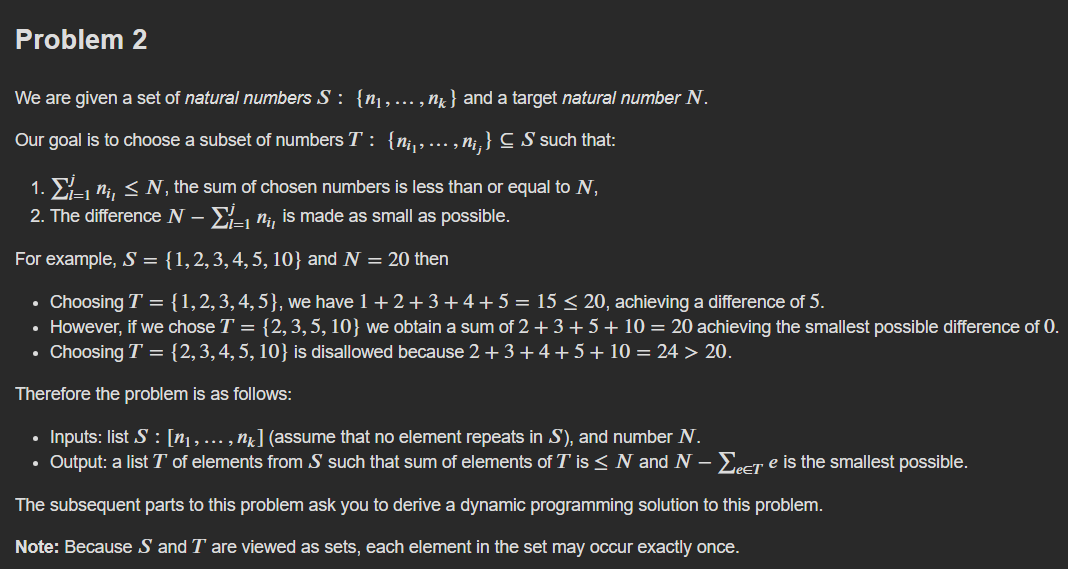

In [18]:
def targetSum_failed_since_ItShouldStoreAllPossiubleValuesNotJustTotalAtEachCell(S, i, tgt):
    n = len(S)
    dp = [None]*n
    previous_index = [None]*n
    
    for x in range(0,n):
        if S[x] > tgt:
            dp[x] = None
        else: #if we get one valid value to start with we can break there
            dp[x] = S[x]
            break
    
    for y in range(x+1,n):
        if S[y] > tgt:
            continue # dp[y] will have None since this cell itself is more than tgt
        max_value = S[y] # current cell value 
        previous_index[y] = None #ideally this line is redudnant though good for readability
        for x in range(0,y): # iterate over all previous totals
            if None == dp[x]:
                continue # we cannot consider this cell 
            if dp[x] + S[y] <= tgt and dp[x] + S[y] > max_value:
                max_value = dp[x] + S[y]
                previous_index[y] = x
        dp[y] = max_value
    maximum_value = max([x for x in dp if not x==None])
    maximum_index = dp.index(maximum_value)
    subsequence = []
    current = maximum_index
    while(current!=None and current>=0):
        subsequence.append(S[current])
        current = previous_index[current]
    subsequence.reverse()
    return tgt-maximum_value

In [21]:
def tgtSum(tgt, S):
    return targetSum(S, 0, tgt)


t3 = (tgtSum(23, [1, 2, 3, 4, 5, 10])) # should be 0
assert t3 == 0, 'Test 3 failed'


AssertionError: Test 3 failed